In [1]:
# importando bibbliotecas#

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#importando Dados # # Como o arquivo csv apresentava o delimitador ";" , foi necessário usar o parametro sep=";"

df = pd.read_csv("Desafio-Segmedic-Python.csv", sep=";")


In [11]:
df.head(5) #Exibindo as 5 prmeiras linhas#

,data_atendimento,paciente_id,nomeprocedimento,grupoprocedimento,valor_pago,retorno,nomeunidade,formapagamento,idprofissional
0,30/01/2024,104593.0,Rx Tornozelo Esquerdo,Raio X,49,Não,Centro Medico Matriz,PIX,18252.0
1,30/01/2024,104593.0,Rx Joelho,Raio X,49,Não,Centro Medico Matriz,PIX,18252.0
2,06/02/2024,166899.0,Consulta Clinica Geral,Clinica Geral,19,Não,Centro Medico Matriz,PIX,18052.0
3,22/02/2024,188620.0,Consulta Clinica Geral,Clinica Geral,19,Não,Centro Medico Matriz,PIX,18190.0
4,26/02/2024,45111.0,Consulta Clinica Geral,Clinica Geral,19,Não,Centro Medico Matriz,PIX,18188.0


In [6]:
df.shape #Qtde de linhas e colunas#

(5084, 9)

In [7]:
df.info() #Verificar os tipos de dados #

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5084 entries, 0 to 5083
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data_atendimento   5084 non-null   object 
 1   paciente_id        5077 non-null   float64
 2   nomeprocedimento   5084 non-null   object 
 3   grupoprocedimento  5084 non-null   object 
 4   valor_pago         5068 non-null   object 
 5   retorno            5084 non-null   object 
 6   nomeunidade        5084 non-null   object 
 7   formapagamento     5084 non-null   object 
 8   idprofissional     5073 non-null   float64
dtypes: float64(2), object(7)
memory usage: 357.6+ KB


In [9]:
df.describe() #Estatisticas essenciais #

,paciente_id,idprofissional
count,5077.000000,5073.000000
mean,174952.905850,12979.709442
std,78220.126073,7506.560949
min,2509.000000,53.000000
25%,133667.000000,6430.000000
50%,197485.000000,17882.000000
75%,228547.000000,18122.000000
max,294634.000000,18664.000000


In [10]:
df.columns #Pesquisar o nome das colunas #

Index(['data_atendimento', 'paciente_id', 'nomeprocedimento',
       'grupoprocedimento', 'valor_pago', 'retorno', 'nomeunidade',
       'formapagamento', 'idprofissional'],
      dtype='object')

Valor atendido por mês

In [12]:
df['data_atendimento'] = pd.to_datetime(df['data_atendimento']) #Convertendo Data

/tmp/ipykernel_173/4189842015.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['data_atendimento'] = pd.to_datetime(df['data_atendimento'])


In [19]:
df['mes'] = df['data_atendimento'].dt.month
 #Criando coluna "mes"


In [54]:
# A coluna 'valor_pago' estava armazenada como tipo string,
# o que fazia o Pandas concatenar valores em vez de somar, foi preciso converter para numérico (float).
# Também foi tratado vírgulas decimais e possíveis valores inválidos.

df['valor_pago'] = df['valor_pago'].astype(str).str.replace(',', '.')
df['valor_pago'] = pd.to_numeric(df['valor_pago'], errors='coerce')

valor_mes = df.groupby('mes')['valor_pago'].sum()

print(valor_mes)



mes
1     516469.05
2      11170.39
3      15454.52
4      11493.87
5      12275.53
6       9294.22
7      20140.63
8      13289.48
9      10362.17
10     14028.24
11     11150.60
12     12806.38
Name: valor_pago, dtype: float64


In [31]:
atendimentos_mes = df.groupby('mes')['grupoprocedimento'].count() #Atendimentos por mes


In [36]:
print(atendimentos_mes)

mes
1     537
2     386
3     514
4     410
5     419
6     287
7     627
8     394
9     308
10    383
11    428
12    391
Name: grupoprocedimento, dtype: int64


In [34]:
top_pacientes = df['paciente_id'].value_counts().head(5) #Top 5 pacientes mais frequentes/ Uso dos atendimentos


In [35]:
print(top_pacientes)

paciente_id
210842.0    82
189892.0    66
6190.0      65
202708.0    61
53863.0     58
Name: count, dtype: int64


In [63]:
meses_pt = {
1: "Jan",
2: "Fev",
3: "Mar",
4: "Abr",
5: "Mai",
6: "Jun",
7: "Jul",
8: "Ago",
9: "Set",
10: "Out",
11: "Nov",
12: "Dez"
}

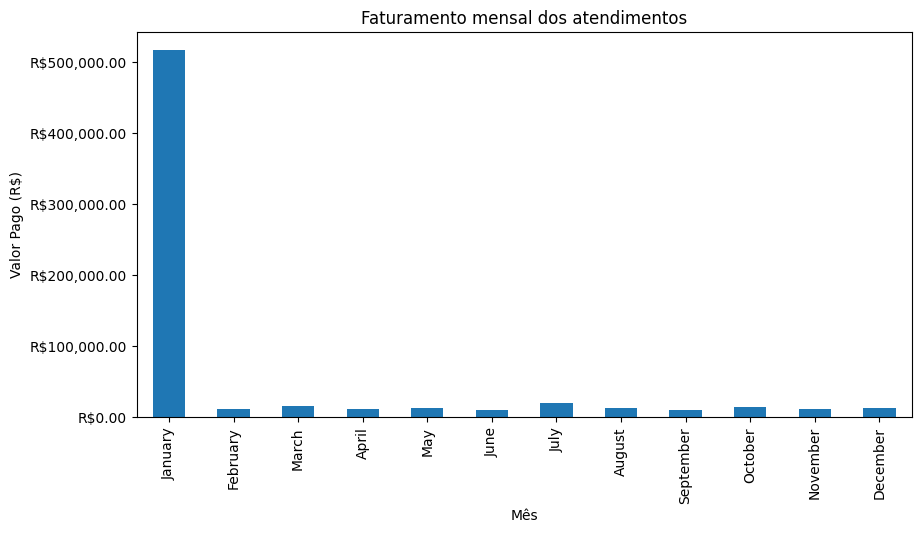

In [67]:

#Plotando gráfico Faturamento mensal dos atendimentos

ax = valor_mes.plot(kind='bar', figsize=(10,5))

plt.title ("Faturamento mensal dos atendimentos")
plt.ylabel  ("Valor Pago (R$)")
plt.xlabel ("Mês")

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('R${x:,.2f}'))

plt.show()



In [65]:
df.groupby(df['data_atendimento'].dt.month)['valor_pago'].describe()

#O faturamento de janeiro é o maior do ano.
#Isso indica que os atendimentos se concentram no início do calendário
# ou que existe uma procura natural por esse serviço nesta época do ano


,count,mean,std,min,25%,50%,75%,max
data_atendimento,,,,,,,,
1,532.0,970.806485,21676.383850,0.0,9.7225,19.99,39.9900,499999.00
2,383.0,29.165509,39.233069,0.0,8.9900,19.00,39.0000,479.00
3,514.0,30.067160,31.111671,0.0,8.9900,19.99,39.9900,229.00
4,409.0,28.102372,29.285142,0.0,8.9900,19.00,39.0000,229.00
5,418.0,29.367297,29.352027,0.0,8.9900,19.99,39.0000,220.00
6,287.0,32.384042,35.240487,0.0,9.9000,22.99,39.9900,243.00
7,626.0,32.173530,36.115821,0.0,9.1900,22.99,45.9225,426.00
8,394.0,33.729645,32.654137,0.0,9.9000,22.99,49.0000,206.58
9,308.0,33.643409,35.789429,0.0,9.9000,22.99,45.9900,213.00


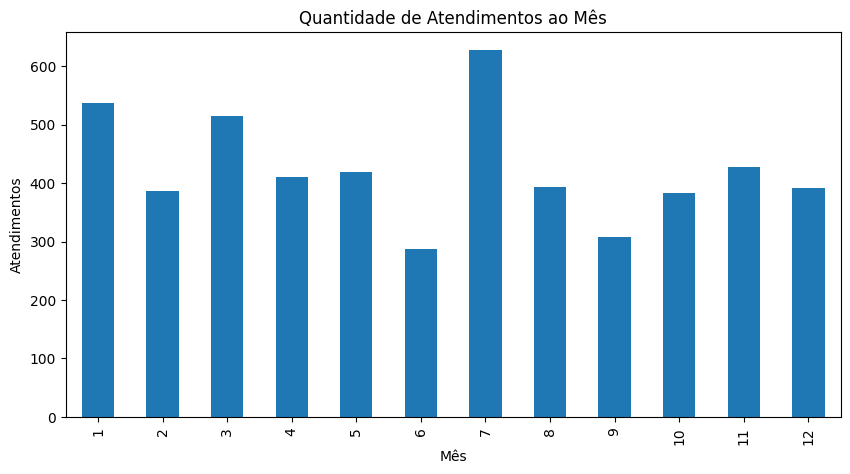

In [69]:
#Plotando gráfico de Qtde. de atendimentos ao mês

atendimentos_mes = df.groupby(df['data_atendimento'].dt.month).size()

atendimentos_mes.plot(kind='bar', figsize=(10,5))

plt.title  ("Quantidade de Atendimentos ao Mês")
plt.ylabel ("Atendimentos")
plt.xlabel ("Mês")

plt.show()

In [70]:
df.groupby(df['data_atendimento'].dt.month).size()

#Foi oservado que os meses de Julho e Janeiro apresentam os maiores volumes de atendimento do ano.
#Esse comportamento sugere uma concentração de demanda em períodos de férias ou início de semestre,
# o que pode indicar uma tendência típica para o setor clínico."


,0
data_atendimento,
1,537
2,386
3,514
4,410
5,419
6,287
7,627
8,394
9,308


In [71]:
#Ticket médio por especialidade
ticket_especialidade = df.groupby('grupoprocedimento')['valor_pago'].mean().sort_values(ascending=False)

ticket_especialidade

,valor_pago
grupoprocedimento,
Raio X,4448.359649
Ecocardiograma Fetal,300.000000
Tomografia,256.857143
Teste Ergométrico,160.000000
Eletroencefalograma,154.833333
Ecocardiograma,123.000000
Demais,109.577600
Ultrassonografia,103.415638
Densitometria Ossea,101.571429
